$$
This \: notebook \: contains \: simulations \: of \: LLN \: and \: CLT \: together \: with \: sketches \: of \: proofs \: for \: LLN
$$

In [118]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

$$
\begin{aligned}
&\text{Let } X_1, X_2, \dots, X_n \sim iid(\mu, \sigma^2) \\
&\text{Then, as } n \to \infty: \\
&\overline{X}_n = \frac{1}{n} \sum_{i=1}^{n} X_i \xrightarrow{P} \mu
\end{aligned}
$$

<Axes: title={'center': 'Uniform Distribution (-1, 1)'}, ylabel='Count'>

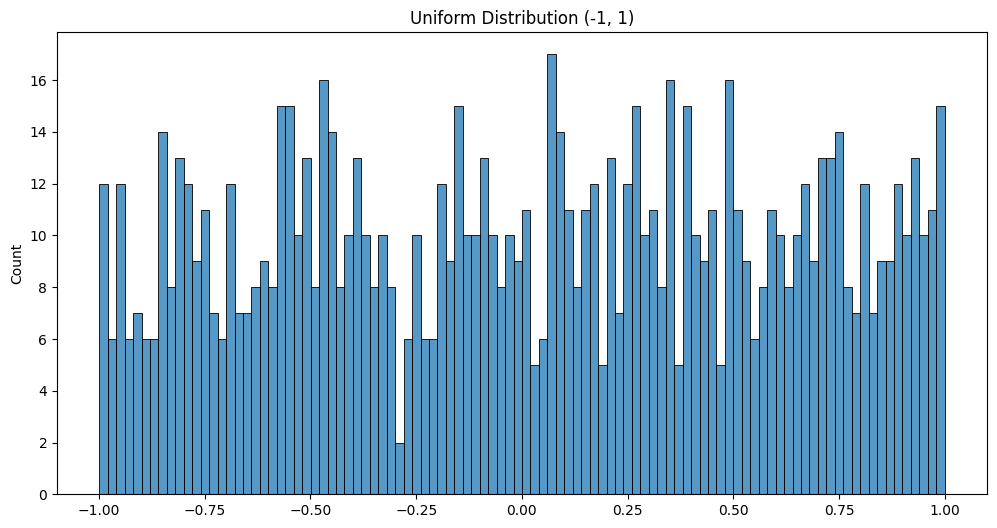

In [119]:
random.seed(42)
plt.figure(figsize=(12, 6))
vars = [random.uniform(-1, 1) for i in range(1000)]
plt.title("Uniform Distribution (-1, 1)")
sns.histplot(vars, bins=100)

$$ SLLN $$

$$
According \: to \: SLLN \: \mathrm{P}(\lim_{n \to \infty}\overline{X_n} = \mu)=1  \\

$$

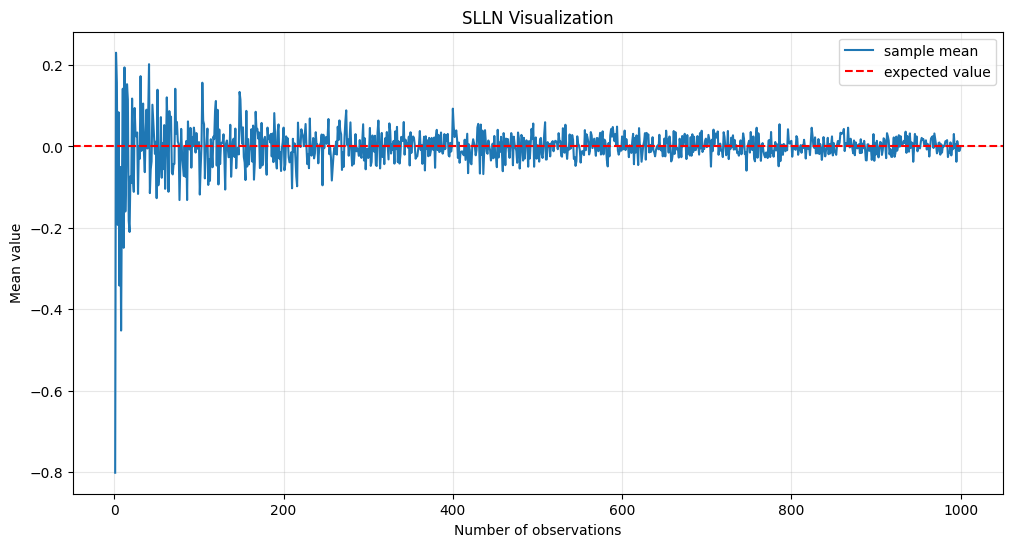

In [120]:
n = 1000
x = np.linspace(1, 1000, 1000)
y = []

for i in range(1, n + 1):
    y.append(sum([random.uniform(-1, 1) for j in range(i)]) / i )

plt.figure(figsize=(12, 6))
plt.grid(True, alpha=0.3)
plt.xlabel("Number of observations")
plt.ylabel("Mean value")

plt.plot(x, y, label = "sample mean")
plt.axhline(y=0, color='red', linestyle='--', label="expected value")
plt.title("SLLN Visualization")
plt.legend()

Expected value for Uniform Distribution is (a + b) / 2 which is 0 in this case

$$
\begin{aligned}
&\text{Convergence of SLLN} \\
&\text{Chebyshev's Inequality shows that: } P(|X - E(X)| \ge \varepsilon) \le \frac{Var(X)}{\varepsilon^2} \\
&P\left(\frac{|X - E(X)|}{\sqrt{\sigma^2/n}} \ge \delta\right) \le \frac{1}{\delta^2} \iff P\left(\frac{|X - E(X)|}{\sqrt{\sigma^2/n}} < \delta\right) \ge 1 - \frac{1}{\delta^2} \\
&\text{Now suppose that } M = \delta \text{ and } \eta = \frac{1}{\delta^2}. \text{ By definition of } O_p: \\
&X_n - \mu = O_p\left(\frac{\sigma}{\sqrt{n}}\right) = O_p\left(\frac{1}{\sqrt{n}}\right) \\
&\text{Note: This is also called } \sqrt{n}\text{-consistency}
\end{aligned}
$$

$$
What\:if\:X_1,X_2,...X_n \: are \: not \: iid \: but \: LLN \: still \: works?
$$

Case 1: Covariance decays over time

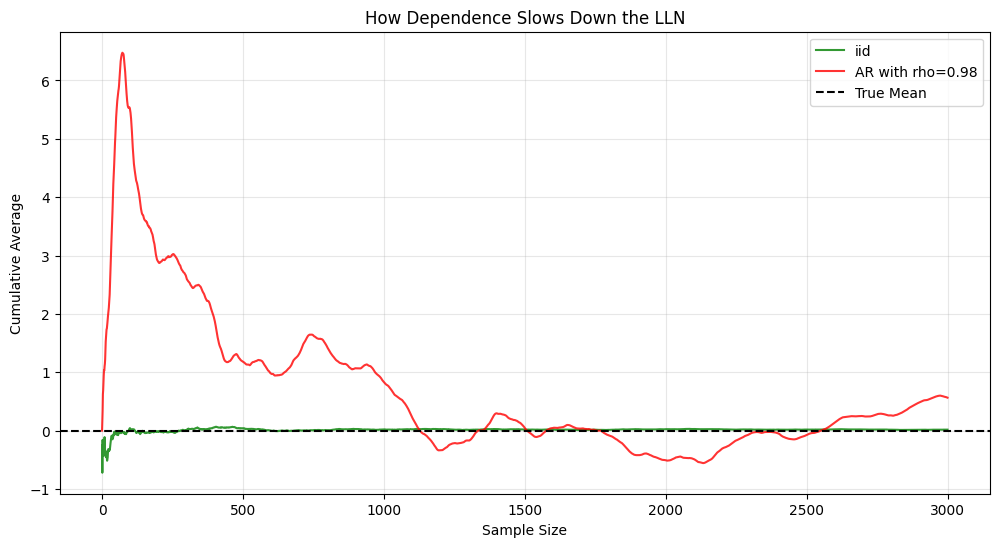

In [126]:
#AR proccess with rho = 0.98
n = 3000
val = np.random.normal(0, 1, n)
avg = np.cumsum(val) / np.arange(1, n + 1)

rho = 0.98
data = np.zeros(n)
for t in range(1, n):
    data[t] = rho * data[t-1] + np.random.normal(0, 1)
avg_ar = np.cumsum(data) / np.arange(1, n + 1)

plt.figure(figsize=(12, 6))
plt.plot(avg, label='iid', color='green', alpha=0.8)
plt.plot(avg_ar, label=f'AR with rho={rho}', color='red', alpha=0.8)
plt.axhline(y=0, color='black', linestyle='--', label='True Mean') #True mean = 0

plt.title('How Dependence Slows Down the LLN')
plt.xlabel('Sample Size')
plt.ylabel('Cumulative Average')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Case 2: Blocks of correlated variables

$$
\begin{aligned}
&\text{If the number of correlated pairs has an order less than } O(n^2), \text{ LLN holds because:} \\
&Var(\overline{X}_n) \approx \frac{Const \cdot n}{n^2} = \frac{Const}{n} \to 0 \text{ as } n \to \infty
\end{aligned}
$$

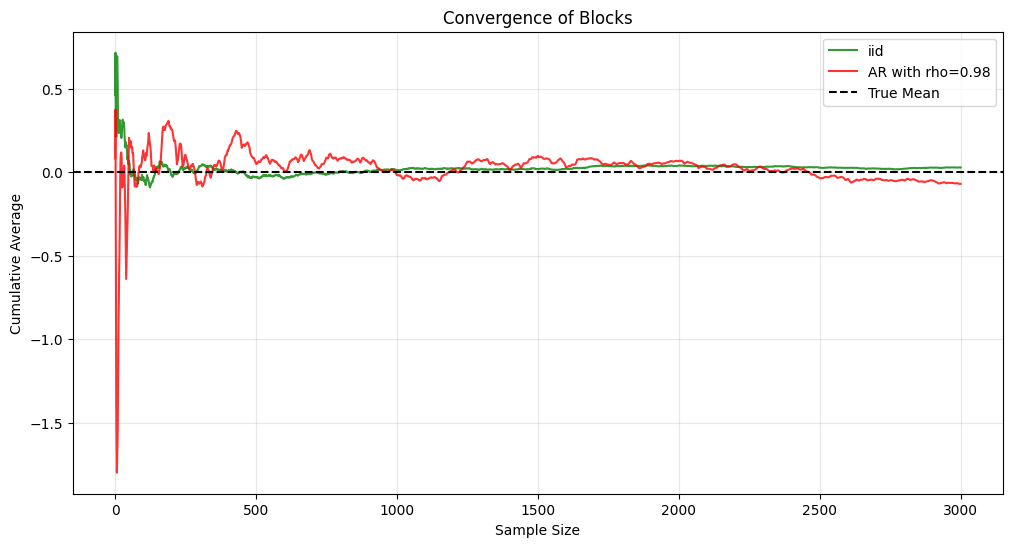

In [125]:
def get_block(n): #Block of AR-vars with size n
    val = np.random.normal(0, 1, n)
    rho = 0.98
    data = np.zeros(n)
    data[0] = np.random.normal(0, 1)
    for t in range(1, n):
        data[t] = rho * data[t-1] + np.random.normal(0, 1)
    return val, data

vals, datas = [], []
n = 300
for i in range(n):
    val, data = get_block(10)
    vals.append(val)
    datas.append(data)
vals = np.concatenate(vals)
datas = np.concatenate(datas)

vals = np.cumsum(vals) / np.arange(1, n * 10 + 1)
datas = np.cumsum(datas) / np.arange(1, n * 10 + 1)

plt.figure(figsize=(12, 6))
plt.plot(vals, label='iid', color='green', alpha=0.8)
plt.plot(datas, label=f'AR with rho={rho}', color='red', alpha=0.8)
plt.axhline(y=0, color='black', linestyle='--', label='True Mean') #True mean = 0
plt.title('Convergence of Blocks')
plt.xlabel('Sample Size')
plt.ylabel('Cumulative Average')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$$ CLT $$

$$
According \: to \: CLT \: \overline{X_n}\:converges\:by\:distribution\:to\:N(\mu,\frac{\sigma^2}{n})
$$

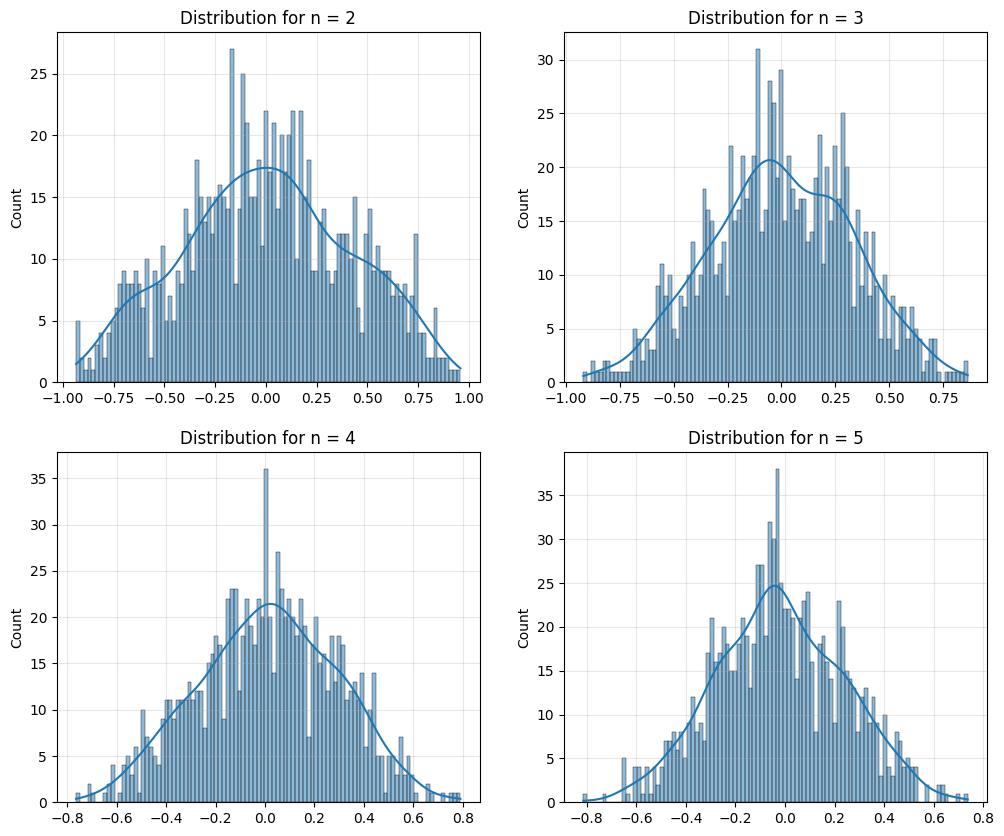

In [123]:
#Visualization of CLT
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for i in range(2, 6):
    cur_ax = ax[i // 2 - 1][i % 2]
    cur_ax.set_title(f"Distribution for n = {i}")
    mean_f = lambda a : sum(a) / len(a)
    dist = [ mean_f([random.uniform(-1, 1) for j in range(i)]) for k in range(1000)]
    cur_ax.grid(True, alpha=0.3)
    sns.histplot(dist, bins=100, kde=True, ax=cur_ax)

The graphs show that the curve is centered around 0 and the variance decreases with increasing n.

$$
\begin{aligned}
&\text{For Uniform Distribution } U(a, b): \\
&E(X) = \mu = \frac{a+b}{2}, \quad Var(X) = \sigma^2 = \frac{(b-a)^2}{12} \\
&\text{By Central Limit Theorem (CLT):} \\
&\overline{X}_n \sim N\left(\mu, \frac{\sigma^2}{n}\right) = N\left(\frac{a+b}{2}, \frac{(b-a)^2}{12n}\right)
\end{aligned}
$$

For n = 10

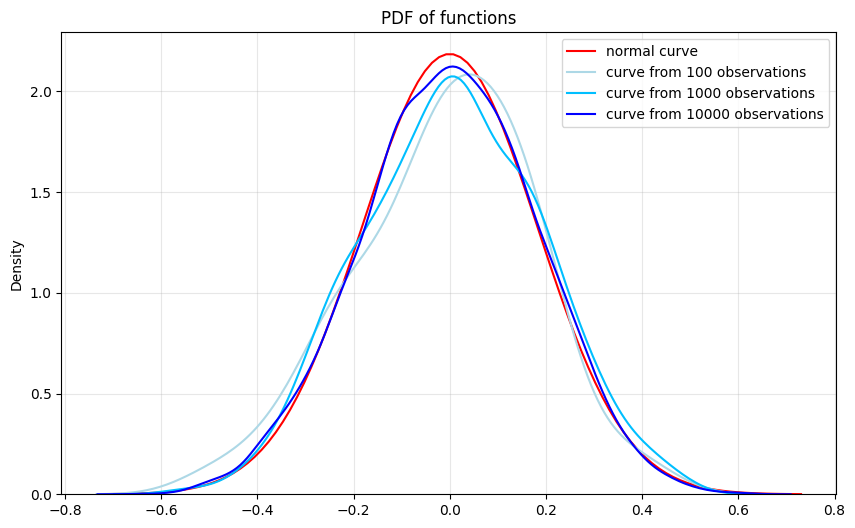

In [124]:

n = 10
x = np.linspace(-1, 1, 200)
fig, ax = plt.subplots(figsize=(10, 6))
mu, sigma = 0, np.sqrt(4 / 120) #mean and std from formulas above

x_values = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y_values = sp.stats.norm.pdf(x_values, loc=mu, scale=sigma)
ax.plot(x_values, y_values, color="red", label="normal curve")

n_observations = [100, 1000, 10000]
colors = ["lightblue", "deepskyblue", "blue"]
plt.title("PDF of functions")

for num in enumerate(n_observations):
    values = [sum([random.uniform(-1, 1) for i in range(n)]) / 10 for j in range(num[1])]
    sns.kdeplot(values, label=f"curve from {num[1]} observations", color=colors[num[0]])

plt.grid(True, alpha=0.3)
plt.legend()